# Impact of LS cocktail on TDCR detection efficiency

Compares **12 commercial LS cocktails** available in TDCRPy for six nuclides:

| Nuclide | Decay | Key physics |
|---------|-------|-------------|
| **H-3**   | Pure β⁻, 18.6 keV           | Low-energy quenching |
| **C-14**  | Pure β⁻, 156 keV             | Medium-energy quenching |
| **Fe-55** | EC + Mn Kα X-rays, 5.9 keV  | Photoelectric (sensitive to P, S, Na, Cl) |
| **Cr-51** | EC + V Kα X-rays, 5.4 keV   | Photoelectric (lower energy than Fe-55) |
| **Co-60** | β⁻ + γ (1.17/1.33 MeV)      | High-energy photon interactions |
| **Cd-109**| EC + Ag-109m IT γ (88 keV)  | Delayed coincidences; eff_S > 1 |

All runs use the **stochastic model** (N = 2000).
Reference cocktail: **Ultima Gold** (residuals relative to it).

In [1]:
pip install TDCRPy==2.20.12

Note: you may need to restart the kernel to use updated packages.


In [2]:
import importlib, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tdcrpy.TDCR_model_lib as tl
import tdcrpy.TDCRPy as tm
from importlib.metadata import version
warnings.filterwarnings('ignore')
print(f'TDCRPy {version("TDCRPy")}')

TDCRPy 2.20.12


## ⚙️ Configuration

In [3]:
L   = 5.0       # free parameter (photons keV-1)
kB  = 1.0e-5    # Birks constant (cm keV-1)
V   = 10        # scintillator volume (mL)
N   = 1000      # Monte-Carlo trials per run (reduced for speed with 6 nuclides)

NUCLIDES = ['H-3', 'C-14', 'Fe-55', 'Cr-51', 'Co-60', 'Cd-109']
NUC_COL  = ['#1f77b4', '#2ca02c', '#e67e22', '#9467bd', '#d62728', '#8c564b']
REF      = 'Ultima Gold'

# Commercial cocktails to compare (pure cocktail, no aqueous fraction)
COCKTAILS = [
    'Ultima Gold',
    'Ultima Gold XR',
    'Ultima Gold AB',
    'Ultima Gold LLT',
    'Insta-Gel Plus',
    'Hionic-Fluor',
    'ProSafe+',
    'ProSafe HC+',
    'Pico-Fluor 40',
    'Pico-Fluor Plus',
    'Aqualight Beta',
    'Permafluor E+',
]

print(f'L={L} photons/keV  kB={kB} cm/keV  V={V} mL  N={N}')
print(f'{len(COCKTAILS)} cocktails x {len(NUCLIDES)} nuclides = {len(COCKTAILS)*len(NUCLIDES)} runs')

L=5.0 photons/keV  kB=1e-05 cm/keV  V=10 mL  N=1000
12 cocktails x 6 nuclides = 72 runs


## 1. Cocktail properties

In [4]:
props = {}
print(f'{"Cocktail":<30} {"rho":>6}  {"Z":>6}  {"A":>6}  {"Z/A":>6}  {"P+S+Na+Cl (%)"}' )
print('─' * 80)
for name in COCKTAILS:
    tl.modifyLScocktail(name, 0.0, 'Water', 0.0)
    tl = importlib.reload(tl)
    Z = tl.Z; A = tl.A; rho = tl.RHO
    heavy = (tl.pP + tl.pS + tl.pNa + tl.pCl) * 100  # atomic % heavy elements
    props[name] = {'Z': Z, 'A': A, 'rho': rho, 'heavy': heavy}
    print(f'{name:<30} {rho:6.4f}  {Z:6.4f}  {A:6.4f}  {Z/A:6.4f}  {heavy:6.3f}')

# Restore
tl.modifyLScocktail('Ultima Gold', 0.0, 'Water', 0.0)
tl = importlib.reload(tl)

Cocktail                          rho       Z       A     Z/A  P+S+Na+Cl (%)
────────────────────────────────────────────────────────────────────────────────
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time =

Ultima Gold                    0.9800  3.2516  5.9449  0.5469   0.348
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold XR
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.99 g/cm3
	Z = 3.2146, A = 5.8553
	Atomic fraction: H=0.5851, C=0.3554, N=0.0007, O=0.0555
	                 P=0.0022, S=0.0006, Na=0.0006, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


Ultima Gold XR                 0.9900  3.2146  5.8553  0.5490   0.332
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold AB
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2382, A = 5.9121
	Atomic fraction: H=0.5732, C=0.3755, N=0.0002, O=0.0509
	                 P=0.0002, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


Ultima Gold AB                 0.9800  3.2382  5.9121  0.5477   0.021
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold LLT
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2381, A = 5.9115
	Atomic fraction: H=0.5735, C=0.3745, N=0.0002, O=0.0516
	                 P=0.0002, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


Ultima Gold LLT                0.9800  3.2381  5.9115  0.5478   0.021
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Insta-Gel Plus
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.9500000000000001 g/cm3
	Z = 3.2483, A = 5.9253
	Atomic fraction: H=0.5796, C=0.3471, N=0.0001, O=0.0731
	                 P=0.0000, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


...

Pico-Fluor 40                  0.9100  3.2504  5.9326  0.5479   0.000
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Pico-Fluor Plus
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.96 g/cm3
	Z = 3.1979, A = 5.8266
	Atomic fraction: H=0.5780, C=0.3784, N=0.0004, O=0.0430
	                 P=0.0002, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


Pico-Fluor Plus                0.9600  3.1979  5.8266  0.5488   0.019
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Aqualight Beta
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.96 g/cm3
	Z = 3.2412, A = 5.9167
	Atomic fraction: H=0.5752, C=0.3695, N=0.0000, O=0.0544
	                 P=0.0010, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


Aqualight Beta                 0.9600  3.2412  5.9167  0.5478   0.096


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Permafluor E+
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.8999999999999999 g/cm3
	Z = 3.1405, A = 5.7106
	Atomic fraction: H=0.5795, C=0.4015, N=0.0000, O=0.0190
	                 P=0.0000, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


Permafluor E+                  0.9000  3.1405  5.7106  0.5499   0.000
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min


## 2. Efficiency scan — stochastic model

In [5]:
# results[cocktail][nuclide] = {'eff_S':, 'u_S':, 'eff_D':, 'u_D':, 'eff_T':, 'u_T':}
results = {c: {} for c in COCKTAILS}

for name in COCKTAILS:
    tl.modifyLScocktail(name, 0.0, 'Water', 0.0)
    tl = importlib.reload(tl)
    import tdcrpy.TDCRPy as tm   # reload TDCRPy to pick up fresh config
    tm = importlib.reload(tm)

    print(f'\n{name}')
    for rad in NUCLIDES:
        r = tm.TDCRPy(L, rad, '1', N, kB, V)
        results[name][rad] = {
            'eff_S': r[0], 'u_S': r[1],
            'eff_D': r[2], 'u_D': r[3],
            'eff_T': r[4], 'u_T': r[5],
        }
        print(f'  {rad:<6}  eff_D={r[2]:.5f}±{r[3]:.5f}  eff_T={r[4]:.5f}±{r[5]:.5f}')

# Restore defaults
tl.modifyLScocktail('Ultima Gold', 0.0, 'Water', 0.0)
tl = importlib.reload(tl)
print('\nDone.')

QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min



Ultima Gold


  H-3     eff_D=0.66378±0.01105  eff_T=0.41400±0.01053


  C-14    eff_D=0.95671±0.00554  eff_T=0.92170±0.00708


  Fe-55   eff_D=0.75033±0.00885  eff_T=0.38718±0.00474


...

  Fe-55   eff_D=0.75424±0.00886  eff_T=0.39258±0.00477


  Cr-51   eff_D=0.69152±0.00751  eff_T=0.30369±0.00449


  Co-60   eff_D=0.97702±0.00383  eff_T=0.95509±0.00548


  Cd-109  eff_D=1.49917±0.01195  eff_T=1.30335±0.01431
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction activated
	Micelle diameter = 2.0 nm (Sigma = 1.0 nm)

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 60.0 min



Done.


## 3. Efficiency comparison — split by nuclide

In [6]:
fig, axes = plt.subplots(6, 2, figsize=(14, 18))
fig.suptitle(f'LS cocktail effect on detection efficiency\nL={L} photons/keV  kB={kB} cm/keV  N={N}',
             fontsize=11)

n_c = len(COCKTAILS)
x   = np.arange(n_c)
w   = 0.35
ref_idx = COCKTAILS.index(REF)

for row, (rad, col) in enumerate(zip(NUCLIDES, NUC_COL)):
    eff_D = np.array([results[c][rad]['eff_D'] for c in COCKTAILS])
    u_D   = np.array([results[c][rad]['u_D']   for c in COCKTAILS])
    eff_T = np.array([results[c][rad]['eff_T'] for c in COCKTAILS])
    u_T   = np.array([results[c][rad]['u_T']   for c in COCKTAILS])

    order  = np.argsort(eff_D)[::-1]
    c_sort = [COCKTAILS[i] for i in order]
    dD_s = eff_D[order]; uD_s = u_D[order]
    dT_s = eff_T[order]; uT_s = u_T[order]
    ref_pos = c_sort.index(REF)

    ax = axes[row, 0]
    bars_D = ax.bar(x - w/2, dD_s, w, yerr=uD_s, capsize=2, color=col, alpha=0.85, label='eff_D')
    bars_T = ax.bar(x + w/2, dT_s, w, yerr=uT_s, capsize=2, color=col, alpha=0.4, hatch='//', label='eff_T')
    bars_D[ref_pos].set_edgecolor('black'); bars_D[ref_pos].set_linewidth(2)
    bars_T[ref_pos].set_edgecolor('black'); bars_T[ref_pos].set_linewidth(2)
    ax.set_xticks(x)
    ax.set_xticklabels(c_sort, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('eff', fontsize=9)
    ax.set_title(f'{rad}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=7, loc='lower right'); ax.grid(axis='y', alpha=0.3)

    ax = axes[row, 1]
    ref_D = results[REF][rad]['eff_D']
    resid = (eff_D - ref_D) * 1e3
    ures  = u_D * 1e3
    colors_r = [col if i != ref_idx else 'gray' for i in range(n_c)]
    ax.axhline(0, color='black', lw=1)
    ax.bar(x, resid, color=colors_r, alpha=0.75, yerr=ures, capsize=2)
    ax.set_xticks(x)
    ax.set_xticklabels(COCKTAILS, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Delta(x1e3)', fontsize=9)
    ax.set_title(f'{rad} residual', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cocktailResponse_efficiency.png', dpi=100, bbox_inches='tight')
plt.close()   # close instead of show to avoid large inline embedding
print('Figure saved: cocktailResponse_efficiency.png')

Figure saved: cocktailResponse_efficiency.png


## 4. Cocktail physical properties

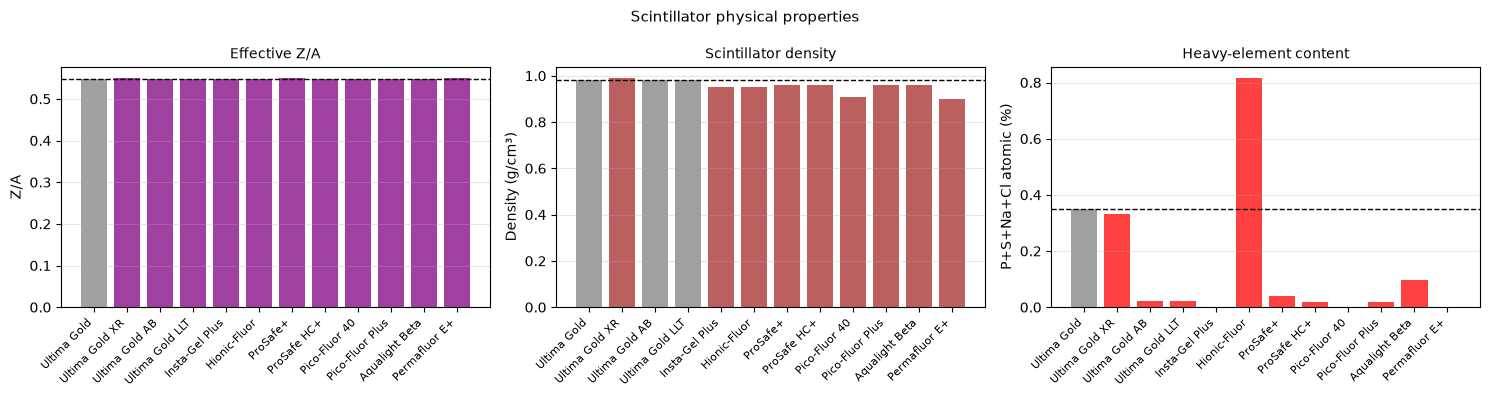

Figure saved.


In [7]:
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
fig2.suptitle('Scintillator physical properties', fontsize=11)

ZA   = [props[c]['Z'] / props[c]['A']   for c in COCKTAILS]
rhos = [props[c]['rho']                  for c in COCKTAILS]
hvy  = [props[c]['heavy']               for c in COCKTAILS]

for ax, vals, ylabel, title, color in [
    (axes2[0], ZA,   'Z/A',                   'Effective Z/A',            'purple'),
    (axes2[1], rhos, 'Density (g/cm³)',        'Scintillator density',     'brown'),
    (axes2[2], hvy,  'P+S+Na+Cl atomic (%)',   'Heavy-element content',    'red'),
]:
    ref_val = vals[COCKTAILS.index(REF)]
    bar_c = [color if v != ref_val else 'gray' for v in vals]
    ax.bar(np.arange(len(COCKTAILS)), vals, color=bar_c, alpha=0.75)
    ax.axhline(ref_val, color='black', lw=1, ls='--')
    ax.set_xticks(np.arange(len(COCKTAILS)))
    ax.set_xticklabels(COCKTAILS, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cocktailResponse_properties.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 5. Correlation: efficiency vs cocktail properties

For pure β emitters (H-3, C-14) quenching depends on Z/A and density.
For Fe-55 (EC + X-ray) the photoelectric cross-section at 5.9 keV
is higher for heavy elements (P, S, Na, Cl with Z > 8), so cocktails
rich in these elements may show a different response.

In [8]:
fig3, axes3 = plt.subplots(2, 3, figsize=(13, 8))
fig3.suptitle('Efficiency vs cocktail properties -- eff_D', fontsize=11)

x_vars = [
    ('Z/A',     [props[c]['Z']/props[c]['A'] for c in COCKTAILS], 'Effective Z/A'),
    ('density', [props[c]['rho']             for c in COCKTAILS], 'Density (g/cm3)'),
    ('heavy',   [props[c]['heavy']           for c in COCKTAILS], 'P+S+Na+Cl atomic (%)'),
]

groups = [
    (['H-3', 'C-14'],                    NUC_COL[:2],  'Pure beta (H-3, C-14)'),
    (['Fe-55','Cr-51','Co-60','Cd-109'], NUC_COL[2:],  'EC/gamma (Fe-55, Cr-51, Co-60, Cd-109)'),
]

idx_ref = COCKTAILS.index(REF)
idx_hio = COCKTAILS.index('Hionic-Fluor')

for col_ax, (xkey, xvals, xlabel) in enumerate(x_vars):
    for row_ax, (rads, cols, gtitle) in enumerate(groups):
        ax = axes3[row_ax, col_ax]
        for r, c in zip(rads, cols):
            yvals = [results[name][r]['eff_D'] for name in COCKTAILS]
            yerrs = [results[name][r]['u_D']   for name in COCKTAILS]
            ax.errorbar(xvals, yvals, yerr=yerrs, fmt='o', color=c, capsize=3,
                        markersize=5, label=r)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel('eff_D', fontsize=9)
        ax.set_title(gtitle, fontsize=9, fontweight='bold')
        ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cocktailResponse_correlations.png', dpi=100, bbox_inches='tight')
plt.close()
print('Figure saved: cocktailResponse_correlations.png')

Figure saved: cocktailResponse_correlations.png


## 6. Summary table

In [9]:
print(f'{"Cocktail":<30} {"rho":>6}  {"Z/A":>6}  {"heavy":>6}  '
      f'{"H-3":>9}  {"C-14":>9}  {"Fe-55":>9}  {"Cr-51":>9}  {"Co-60":>9}  {"Cd-109":>9}')
print('-' * 115)

# Sort by Fe-55 eff_D (most physically informative for cocktail selection)
sorted_c = sorted(COCKTAILS, key=lambda c: results[c]['Fe-55']['eff_D'], reverse=True)

for name in sorted_c:
    p = props[name]
    vals = [f'{results[name][r]["eff_D"]:.5f}' for r in NUCLIDES]
    marker = ' (REF)' if name == REF else ''
    print(f'{name:<30} {p["rho"]:6.4f}  {p["Z"]/p["A"]:6.4f}  {p["heavy"]:6.3f}  '
          + '  '.join(vals) + marker)

Cocktail                          rho     Z/A   heavy        H-3       C-14      Fe-55      Cr-51      Co-60     Cd-109
-------------------------------------------------------------------------------------------------------------------
Insta-Gel Plus                 0.9500  0.5482   0.000  0.64230  0.95908  0.76370  0.69739  0.98162  1.47599
Hionic-Fluor                   0.9500  0.5484   0.816  0.63978  0.96684  0.76103  0.67872  0.98217  1.47215
ProSafe+                       0.9600  0.5498   0.040  0.64369  0.95430  0.75433  0.67010  0.97674  1.48705
Permafluor E+                  0.9000  0.5499   0.000  0.63813  0.94950  0.75424  0.69152  0.97702  1.49917
Ultima Gold LLT                0.9800  0.5478   0.021  0.64925  0.95948  0.75294  0.67480  0.97778  1.47939
Aqualight Beta                 0.9600  0.5478   0.096  0.64057  0.96031  0.75203  0.68789  0.97699  1.49041
ProSafe HC+                    0.9600  0.5479   0.019  0.63011  0.95834  0.75146  0.69137  0.97895  1.51202
Ultima G